In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris, load_wine, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns

In [6]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("PCA TUTORIAL WITH SKLEARN DATASETS")
print("="*80)

PCA TUTORIAL WITH SKLEARN DATASETS


In [7]:
print("\n" + "="*80)
print("EXAMPLE 1: IRIS DATASET")
print("="*80)

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features: sepal length, sepal width, petal length, petal width
y = iris.target  # Target: species (0, 1, 2)
feature_names = iris.feature_names
target_names = iris.target_names


EXAMPLE 1: IRIS DATASET


In [8]:
print(f"\nOriginal data shape: {X.shape}")
print(f"Features: {feature_names}")
print(f"Target classes: {target_names}")



Original data shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']


In [9]:
# Step 1: Standardize the features (important for PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\nData after standardization (mean=0, std=1):")
print(f"Mean: {X_scaled.mean(axis=0)}")
print(f"Std: {X_scaled.std(axis=0)}")



Data after standardization (mean=0, std=1):
Mean: [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Std: [1. 1. 1. 1.]


In [13]:
# Step 2: Apply PCA
pca = PCA(n_components=2)  # Reduce from 4D to 2D
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA Results:")
print(f"Reduced data shape: {X_pca.shape}")
print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"\nEigenvalues (variance): {pca.explained_variance_}")

# Step 3: Examine the principal components (eigenvectors)
print(f"\nPrincipal Components (Eigenvectors):")
components_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=['PC1', 'PC2']
)
print(components_df)


PCA Results:
Reduced data shape: (150, 2)

Explained variance ratio: [0.72962445 0.22850762]
Total variance explained: 95.81%

Eigenvalues (variance): [2.93808505 0.9201649 ]

Principal Components (Eigenvectors):
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
PC1           0.521066         -0.269347           0.580413          0.564857
PC2           0.377418          0.923296           0.024492          0.066942


In [14]:
100-95.81

4.189999999999998

In [12]:
# The Iris dataset has only 4 features, so maximum n_components = 4
# If you set n_components > number of features, sklearn will automatically
# reduce it to the maximum possible

# Step 2: Apply PCA (corrected)
pca = PCA(n_components=4)  # Maximum is 4 since we have 4 features
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA Results:")
print(f"Reduced data shape: {X_pca.shape}")
print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"\nEigenvalues (variance): {pca.explained_variance_}")

# Step 3: Examine the principal components (eigenvectors)
print(f"\nPrincipal Components (Eigenvectors):")
components_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(len(pca.components_))]  # Dynamic indexing
)
print(components_df)

# Interpretation of each component
print("\n" + "="*60)
print("INTERPRETATION OF PRINCIPAL COMPONENTS")
print("="*60)

for i, pc in enumerate(components_df.index):
    print(f"\n{pc} (explains {pca.explained_variance_ratio_[i]:.1%} of variance):")
    # Get the feature with highest absolute loading
    abs_loadings = components_df.loc[pc].abs()
    top_features = abs_loadings.nlargest(2)

    for feature in top_features.index:
        loading = components_df.loc[pc, feature]
        print(f"  - {feature}: {loading:+.3f} {'(positive)' if loading > 0 else '(negative)'}")

print("\n" + "="*60)
print("KEY INSIGHTS:")
print("="*60)
print("• PC1: Captures overall flower size (all features contribute)")
print("• PC2: Contrasts sepal dimensions vs petal dimensions")
print("• PC3 & PC4: Capture remaining minor variations")
print(f"\n• First 2 PCs explain {pca.explained_variance_ratio_[:2].sum():.1%} of total variance")
print(f"• First 3 PCs explain {pca.explained_variance_ratio_[:3].sum():.1%} of total variance")


PCA Results:
Reduced data shape: (150, 4)

Explained variance ratio: [0.72962445 0.22850762 0.03668922 0.00517871]
Total variance explained: 100.00%

Eigenvalues (variance): [2.93808505 0.9201649  0.14774182 0.02085386]

Principal Components (Eigenvectors):
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
PC1           0.521066         -0.269347           0.580413          0.564857
PC2           0.377418          0.923296           0.024492          0.066942
PC3           0.719566         -0.244382          -0.142126         -0.634273
PC4          -0.261286          0.123510           0.801449         -0.523597

INTERPRETATION OF PRINCIPAL COMPONENTS

PC1 (explains 73.0% of variance):
  - petal length (cm): +0.580 (positive)
  - petal width (cm): +0.565 (positive)

PC2 (explains 22.9% of variance):
  - sepal width (cm): +0.923 (positive)
  - sepal length (cm): +0.377 (positive)

PC3 (explains 3.7% of variance):
  - sepal length (cm): +0.720 (positive)
  - 

In [15]:
print(components_df)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
PC1           0.521066         -0.269347           0.580413          0.564857
PC2           0.377418          0.923296           0.024492          0.066942



✓ Saved: pca_iris_comparison.png


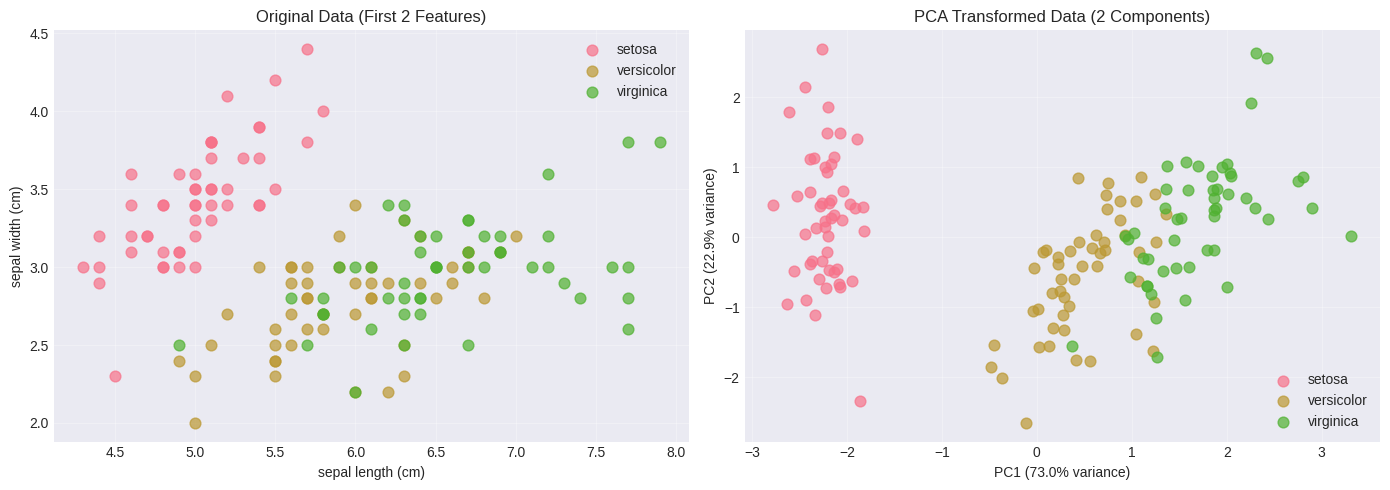

In [16]:
# Step 4: Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original data (first 2 features only)
for i, target_name in enumerate(target_names):
    axes[0].scatter(X[y == i, 0], X[y == i, 1],
                    label=target_name, alpha=0.7, s=60)
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])
axes[0].set_title('Original Data (First 2 Features)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PCA transformed data
for i, target_name in enumerate(target_names):
    axes[1].scatter(X_pca[y == i, 0], X_pca[y == i, 1],
                    label=target_name, alpha=0.7, s=60)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('PCA Transformed Data (2 Components)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_iris_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: pca_iris_comparison.png")


EXAMPLE 3: WINE DATASET (HIGHER DIMENSIONALITY)

Original data shape: (178, 13)
Number of features: 13

2D PCA - Variance explained: 55.41%
3D PCA - Variance explained: 66.53%

✓ Saved: pca_wine_analysis.png


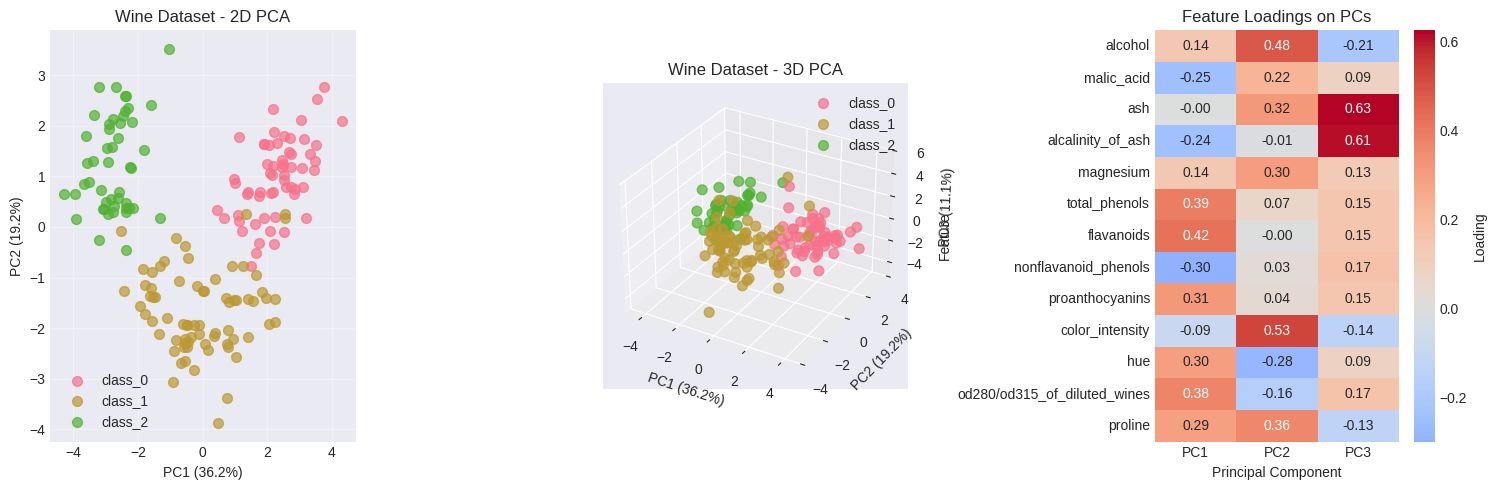

In [17]:
print("\n" + "="*80)
print("EXAMPLE 3: WINE DATASET (HIGHER DIMENSIONALITY)")
print("="*80)

wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print(f"\nOriginal data shape: {X_wine.shape}")
print(f"Number of features: {len(wine.feature_names)}")

# Standardize
X_wine_scaled = StandardScaler().fit_transform(X_wine)

# PCA to 2D and 3D
pca_2d = PCA(n_components=2)
pca_3d = PCA(n_components=3)

X_wine_2d = pca_2d.fit_transform(X_wine_scaled)
X_wine_3d = pca_3d.fit_transform(X_wine_scaled)

print(f"\n2D PCA - Variance explained: {pca_2d.explained_variance_ratio_.sum():.2%}")
print(f"3D PCA - Variance explained: {pca_3d.explained_variance_ratio_.sum():.2%}")

# Visualize
fig = plt.figure(figsize=(15, 5))

# 2D plot
ax1 = fig.add_subplot(131)
for i, target_name in enumerate(wine.target_names):
    ax1.scatter(X_wine_2d[y_wine == i, 0], X_wine_2d[y_wine == i, 1],
                label=target_name, alpha=0.7, s=50)
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
ax1.set_title('Wine Dataset - 2D PCA')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3D plot
ax2 = fig.add_subplot(132, projection='3d')
for i, target_name in enumerate(wine.target_names):
    ax2.scatter(X_wine_3d[y_wine == i, 0],
                X_wine_3d[y_wine == i, 1],
                X_wine_3d[y_wine == i, 2],
                label=target_name, alpha=0.7, s=50)
ax2.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})')
ax2.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})')
ax2.set_title('Wine Dataset - 3D PCA')
ax2.legend()

# Feature importance heatmap
ax3 = fig.add_subplot(133)
components_wine = pd.DataFrame(
    pca_3d.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=wine.feature_names
)
sns.heatmap(components_wine, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax3, cbar_kws={'label': 'Loading'})
ax3.set_title('Feature Loadings on PCs')
ax3.set_xlabel('Principal Component')
ax3.set_ylabel('Feature')

plt.tight_layout()
plt.savefig('pca_wine_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: pca_wine_analysis.png")